In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import save
import scipy
from scipy import stats
# import cv2
from pathlib import Path
import seaborn as sns
from matplotlib import cm
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as plticker
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu
import os
from scipy.stats import circmean, circstd
import cv2
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress
from scipy.stats import spearmanr, pearsonr

In [20]:
stimuli = ['fex_1_10', 'kin_water', 'proline_100mM', 'adenosine_2.5mM', 'cadaverine_25mM', 'HCl_56mM', 'quinine_100mM']

   
# Filtering thresholds 
movement_threshold = 60
tracking_threshold = 90
# jump_threshold = 500

# Load dataframes from a given folder
def load_dataframes_from_folder(folder):
    dataframes = []

    for file in folder.iterdir():
        if file.suffix == ".csv":
            df = pd.read_csv(file)
            dataframes.append(df)

    return dataframes
    
# Function to check if fish are moving significantly
def total_distance_travelled(df):
    dx = df['x'][df['mask']].diff()
    dy = df['y'][df['mask']].diff()
    return np.sqrt(dx**2 + dy**2).sum()

def is_fish_significantly_moving(df, movement_threshold, tracking_threshold):
    total_frames = len(df)
    tracked_frames = len(df[df["mask"]])
    
    tracking_percentage = (tracked_frames / total_frames) * 100
    if tracking_percentage < tracking_threshold:
        return False
    
    valid_data = df[df["mask"]]
    return total_distance_travelled(valid_data) > movement_threshold

## Load in the data 

In [21]:
stimulus_data = {}

for stimulus in stimuli:
    parent_dir = Path(f"/Volumes/LaCie/free_swimming/7dpf_TRex/{stimulus}")
    stimulus_data[stimulus] = {'stim': {}, 'control': {}}

    for condition in ['stim', 'control']:
        condition_dir = parent_dir / condition

        for exp_folder in condition_dir.iterdir():
            if not exp_folder.is_dir():
                continue

            exp_name = exp_folder.name

            # use a folder-level loader here
            fish_dfs = load_dataframes_from_folder(exp_folder)

            filtered_fish = [
                fish_df for fish_df in fish_dfs
                if is_fish_significantly_moving(
                    fish_df, movement_threshold, tracking_threshold
                )
            ]

            stimulus_data[stimulus][condition][exp_name] = filtered_fish

## Helper Functions

In [22]:
def time_spent_in_left_half_last_half(df, frame_rate):
    start_index = len(df) // 2
    last_half_df = df.iloc[start_index:]

    valid_data = last_half_df[last_half_df["mask"]]

    time_in_left_half = len(valid_data[valid_data["x"] < 7]) / frame_rate  
    total_valid_time = len(valid_data) / frame_rate

    return time_in_left_half, total_valid_time


def calculate_fish_preference_indices(dataframes, frame_rate):
    fish_preferences = []

    for df in dataframes:
        left_time, total_time = time_spent_in_left_half_last_half(df, frame_rate)
        pref = (left_time / total_time) * 100 if total_time > 0 else np.nan
        fish_preferences.append(pref)

    return fish_preferences


def get_pair_key(exp_name):
    parts = exp_name.split("_")
    return "_".join(parts[:2])   # e.g. 231221_G1

### Speed functions

In [23]:


def average_speed_in_zone_last_half(df, x_limit, speed_threshold=3.0):
    """
    Mean speed in last half of trial within spatial zone (x < x_limit).
    Returned in mm/s.
    """

    start_index = len(df) // 2
    last_half_df = df.iloc[start_index:]

    valid_data = last_half_df[last_half_df["mask"]]

    filtered = valid_data[
        (valid_data["x"] < x_limit) & 
        (valid_data["speed"] < speed_threshold)
    ]

    if filtered.empty:
        return np.nan

    return filtered["speed"].mean() * 10   # convert cm/s → mm/s


def compute_avg_speeds_zone(dataframes, x_limit, speed_threshold=3.0):

    return [
        average_speed_in_zone_last_half(df, x_limit, speed_threshold)
        for df in dataframes
    ]

### Dispersion and Center shift functions

In [24]:

def compute_minimum_enclosing_circle(points):
    """
    Compute minimum enclosing circle radius and center for a set of 2D points.
    """
    if len(points) < 2:
        return np.nan, (np.nan, np.nan)

    points = np.asarray(points, dtype=np.float32)
    (cx, cy), radius = cv2.minEnclosingCircle(points)
    return radius, (cx, cy)

def smooth_positions(
    df,
    time_column="time",
    x_column="x",
    y_column="y",
    smoothing_factor=0.5
):
    """
    Smooth x and y positions using cubic spline interpolation.
    Returns a copy of the dataframe.
    """
    df = df.copy()

    times = df[time_column].values
    x_vals = df[x_column].values
    y_vals = df[y_column].values

    if len(df) < 4:
        return df

    spline_x = UnivariateSpline(times, x_vals, s=smoothing_factor * len(times))
    spline_y = UnivariateSpline(times, y_vals, s=smoothing_factor * len(times))

    df[x_column] = spline_x(times)
    df[y_column] = spline_y(times)

    return df

def prepare_zone_data(
    df,
    x_limit,
    time_column="time",
    x_column="x",
    y_column="y",
    mask_column="mask",
    speed_column="speed",
    speed_threshold=3.0,
    smoothing_factor=0.5
):
    """
    Prepare filtered/smoothed dataframe for zone-based spatial analyses.
    Keeps only the last half of the trial.
    """
    df = df.copy()

    # last half
    midpoint = len(df) // 2
    df = df.iloc[midpoint:].copy()

    # valid frames + speed filter
    df = df[
        (df[mask_column]) &
        (df[speed_column] < speed_threshold)
    ].copy()

    df = df.dropna(subset=[time_column, x_column, y_column])

    if len(df) < 5:
        return pd.DataFrame()

    # zone restriction
    df = df[df[x_column] < x_limit].copy() 

    # smooth
    df = smooth_positions(
        df,
        time_column=time_column,
        x_column=x_column,
        y_column=y_column,
        smoothing_factor=smoothing_factor
    )

    if len(df) < 5:
        return pd.DataFrame()

    return df

def compute_dispersion(
    df,
    x_limit,
    time_column="time",
    x_column="x",
    y_column="y",
    mask_column="mask",
    speed_column="speed",
    bin_size=3,
    smoothing_factor=0.5,
    speed_threshold=3.0
):
    """
    Compute mean dispersion for one fish in a zone.
    Dispersion = mean radius of minimum enclosing circle across time bins.
    """
    df = prepare_zone_data(
        df=df,
        x_limit=x_limit,
        time_column=time_column,
        x_column=x_column,
        y_column=y_column,
        mask_column=mask_column,
        speed_column=speed_column,
        speed_threshold=speed_threshold,
        smoothing_factor=smoothing_factor
    )

    if df.empty:
        return np.nan

    df["time_bin"] = (df[time_column] // bin_size).astype(int) * bin_size

    radii = []

    for t in sorted(df["time_bin"].unique()):
        subset = df[df["time_bin"] == t][[x_column, y_column]].dropna()

        if len(subset) >= 2:
            radius, _ = compute_minimum_enclosing_circle(subset.values)
            radii.append(radius)

    return np.nanmean(radii) if len(radii) > 0 else np.nan

def compute_fish_center_shift(
    df,
    x_limit,
    time_column="time",
    x_column="x",
    y_column="y",
    mask_column="mask",
    speed_column="speed",
    bin_size=3,
    smoothing_factor=0.5,
    speed_threshold=3.0
):
    """
    Compute mean center shift for one fish in a zone.
    Center shift = mean distance between enclosing-circle centers in consecutive bins.
    """
    df = prepare_zone_data(
        df=df,
        x_limit=x_limit,
        time_column=time_column,
        x_column=x_column,
        y_column=y_column,
        mask_column=mask_column,
        speed_column=speed_column,
        speed_threshold=speed_threshold,
        smoothing_factor=smoothing_factor
    )

    if df.empty:
        return np.nan

    df["time_bin"] = (df[time_column] // bin_size).astype(int) * bin_size

    centers = []

    for t in sorted(df["time_bin"].unique()):
        subset = df[df["time_bin"] == t][[x_column, y_column]].dropna()

        if len(subset) >= 2:
            _, (cx, cy) = compute_minimum_enclosing_circle(subset.values)
            centers.append((t, cx, cy))

    shifts = []

    for (_, x1, y1), (_, x2, y2) in zip(centers[:-1], centers[1:]):
        shift = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        shifts.append(shift)

    return np.nanmean(shifts) if len(shifts) > 0 else np.nan


def compute_fish_dispersions(
    fish_list,
    x_limit,
    time_column="time",
    x_column="x",
    y_column="y",
    mask_column="mask",
    speed_column="speed",
    bin_size=10,
    smoothing_factor=0.5,
    speed_threshold=3.0
):
    return [
        compute_dispersion(
            df=fish_df,
            x_limit=x_limit,
            time_column=time_column,
            x_column=x_column,
            y_column=y_column,
            mask_column=mask_column,
            speed_column=speed_column,
            bin_size=bin_size,
            smoothing_factor=smoothing_factor,
            speed_threshold=speed_threshold
        )
        for fish_df in fish_list
    ]


def compute_fish_center_shifts(
    fish_list,
    x_limit,
    time_column="time",
    x_column="x",
    y_column="y",
    mask_column="mask",
    speed_column="speed",
    bin_size=10,
    smoothing_factor=0.5,
    speed_threshold=3.0
):
    return [
        compute_fish_center_shift(
            df=fish_df,
            x_limit=x_limit,
            time_column=time_column,
            x_column=x_column,
            y_column=y_column,
            mask_column=mask_column,
            speed_column=speed_column,
            bin_size=bin_size,
            smoothing_factor=smoothing_factor,
            speed_threshold=speed_threshold
        )
        for fish_df in fish_list
    ]

### Bout detection and angle calculations 

In [25]:
# =========================================================
# 1. BOUT DETECTION
# =========================================================

def find_bouts(speed, threshold=0.5, min_duration=1, expand=1, gap_tolerance=2, max_speed=3.0):
    """
    Find bouts from a speed trace.

    Parameters
    ----------
    speed : array-like
        Speed trace.
    threshold : float
        Minimum speed for a bout.
    min_duration : int
        Minimum number of consecutive samples above threshold.
    expand : int
        Expand each bout by this many frames before and after.
    gap_tolerance : int
        Merge bouts separated by <= this many frames.
    max_speed : float
        Ignore speeds above this value.

    Returns
    -------
    bouts : list of tuple
        List of (start_idx, end_idx) bout boundaries.
    """
    speed = np.asarray(speed, dtype=float)

    valid_speed = (speed > threshold) & (speed <= max_speed)
    valid_speed = np.nan_to_num(valid_speed, nan=False)

    bouts = []
    start_idx = None

    for i, is_valid in enumerate(valid_speed):
        if is_valid and start_idx is None:
            start_idx = i

        elif not is_valid and start_idx is not None:
            if (i - start_idx) >= min_duration:
                bout_start = max(0, start_idx - expand)
                bout_end = min(len(speed) - 1, i - 1 + expand)

                if bouts and (bout_start - bouts[-1][1] <= gap_tolerance):
                    bouts[-1] = (bouts[-1][0], bout_end)
                else:
                    bouts.append((bout_start, bout_end))

            start_idx = None

    if start_idx is not None and (len(speed) - start_idx) >= min_duration:
        bout_start = max(0, start_idx - expand)
        bout_end = len(speed) - 1

        if bouts and (bout_start - bouts[-1][1] <= gap_tolerance):
            bouts[-1] = (bouts[-1][0], bout_end)
        else:
            bouts.append((bout_start, bout_end))

    return bouts


# =========================================================
# 2. ROBUST BOUT ENDPOINT HANDLING
# =========================================================

def get_valid_bout_endpoint(df, start, end, which="start", mask_col="mask", x_col="x", y_col="y"):
    """
    Find a valid tracked frame within a bout to use as the bout start or end.

    Parameters
    ----------
    df : pd.DataFrame
    start, end : int
        Bout boundaries.
    which : str
        "start" -> search forward from start
        "end"   -> search backward from end

    Returns
    -------
    idx : int or None
        Valid frame index, or None if no valid frame exists in the bout.
    """
    if which == "start":
        indices = range(start, end + 1)
    elif which == "end":
        indices = range(end, start - 1, -1)
    else:
        raise ValueError("which must be 'start' or 'end'")

    for idx in indices:
        if (
            bool(df.loc[idx, mask_col]) and
            pd.notna(df.loc[idx, x_col]) and
            pd.notna(df.loc[idx, y_col])
        ):
            return idx

    return None


def get_heading_from_bout(df, start, end, mask_col="mask", x_col="x", y_col="y"):
    """
    Compute heading angle for a bout using the nearest valid start/end frames.

    Returns
    -------
    heading : float or None
        Heading angle in radians, or None if invalid.
    x_mean : float or np.nan
        Mean x-position across valid tracked frames in the bout.
    """
    start_valid = get_valid_bout_endpoint(df, start, end, which="start",
                                          mask_col=mask_col, x_col=x_col, y_col=y_col)
    end_valid = get_valid_bout_endpoint(df, start, end, which="end",
                                        mask_col=mask_col, x_col=x_col, y_col=y_col)

    if start_valid is None or end_valid is None:
        return None, np.nan

    x0 = df.loc[start_valid, x_col]
    y0 = df.loc[start_valid, y_col]
    x1 = df.loc[end_valid, x_col]
    y1 = df.loc[end_valid, y_col]

    dx = x1 - x0
    dy = y1 - y0

    # Skip zero-length bouts
    if dx == 0 and dy == 0:
        return None, np.nan

    heading = np.arctan2(dy, dx)

    valid_bout_frames = df.loc[start:end]
    valid_bout_frames = valid_bout_frames[
        valid_bout_frames[mask_col] &
        valid_bout_frames[x_col].notna()
    ]
    x_mean = valid_bout_frames[x_col].mean() if not valid_bout_frames.empty else np.nan

    return heading, x_mean


# =========================================================
# 3. FISH-LEVEL ANGLE CHANGE METRIC
# =========================================================

def compute_mean_bout_angle_change(
    fish_df,
    x_limit=7,
    last_half_only=True,
    mask_col="mask",
    speed_col="speed",
    x_col="x",
    y_col="y",
    bout_threshold=0.5,
    bout_min_duration=1,
    bout_expand=1,
    bout_gap_tolerance=2,
    bout_max_speed=3.0
):
    """
    Compute mean angular change (degrees) between consecutive bouts for one fish.

    Rules:
    - Bouts are detected from speed
    - Invalid tracking frames are excluded from bout endpoint selection
    - Only bout pairs whose current bout lies in the specified zone (x < x_limit) are included
    - Optionally restrict to the last half of the trial

    Returns
    -------
    mean_angle_change_deg : float
        Mean angle change between consecutive bouts, in degrees.
    """
    df = fish_df.copy()

    # Mask invalid speed values before bout detection
    speed = df[speed_col].copy()
    speed.loc[~df[mask_col]] = np.nan

    bouts = find_bouts(
        speed=speed.values,
        threshold=bout_threshold,
        min_duration=bout_min_duration,
        expand=bout_expand,
        gap_tolerance=bout_gap_tolerance,
        max_speed=bout_max_speed
    )

    if last_half_only:
        midpoint = len(df) // 2
        bouts = [b for b in bouts if b[0] >= midpoint]

    angle_changes = []

    for i in range(1, len(bouts)):
        prev_start, prev_end = bouts[i - 1]
        curr_start, curr_end = bouts[i]

        prev_heading, _ = get_heading_from_bout(
            df, prev_start, prev_end,
            mask_col=mask_col, x_col=x_col, y_col=y_col
        )
        curr_heading, curr_x_mean = get_heading_from_bout(
            df, curr_start, curr_end,
            mask_col=mask_col, x_col=x_col, y_col=y_col
        )

        # Skip invalid bouts
        if prev_heading is None or curr_heading is None:
            continue

        # Restrict to spatial zone
        if pd.isna(curr_x_mean) or curr_x_mean >= x_limit: 
            continue

        angle_diff = np.abs(curr_heading - prev_heading)
        if angle_diff > np.pi:
            angle_diff = 2 * np.pi - angle_diff

        angle_changes.append(np.degrees(angle_diff))

    return np.nanmean(angle_changes) if len(angle_changes) > 0 else np.nan


def compute_fish_bout_angle_changes(
    fish_list,
    x_limit=7,
    last_half_only=True,
    mask_col="mask",
    speed_col="speed",
    x_col="x",
    y_col="y",
    bout_threshold=0.5,
    bout_min_duration=1,
    bout_expand=1,
    bout_gap_tolerance=2,
    bout_max_speed=3.0
):
    """
    Compute one mean bout-angle-change value per fish.
    """
    return [
        compute_mean_bout_angle_change(
            fish_df=fish_df,
            x_limit=x_limit,
            last_half_only=last_half_only,
            mask_col=mask_col,
            speed_col=speed_col,
            x_col=x_col,
            y_col=y_col,
            bout_threshold=bout_threshold,
            bout_min_duration=bout_min_duration,
            bout_expand=bout_expand,
            bout_gap_tolerance=bout_gap_tolerance,
            bout_max_speed=bout_max_speed
        )
        for fish_df in fish_list
    ]


# =========================================================
# 4. EXISTING METRICS
# =========================================================


### Get all metrics calculated for each experiment averaged over fish 

In [26]:
def summarize_experiment(
    fish_list,
    frame_rate,
    speed_threshold=3.0,
    dispersion_bin_size=3,
    dispersion_smoothing_factor=0.5
):
    """
    Fast experiment summary with separate metrics.
    """

    # preference
    fish_prefs = calculate_fish_preference_indices(fish_list, frame_rate)
    preference_index = np.nanmean(fish_prefs) if len(fish_prefs) > 0 else np.nan

    # speed
    fish_speed_half = compute_avg_speeds_zone(
        fish_list,
        x_limit=7,
        speed_threshold=speed_threshold
    )
    speed_half = np.nanmean(fish_speed_half) if len(fish_speed_half) > 0 else np.nan

    fish_speed_quarter = compute_avg_speeds_zone(
        fish_list,
        x_limit=3.5,
        speed_threshold=speed_threshold
    )
    speed_quarter = np.nanmean(fish_speed_quarter) if len(fish_speed_quarter) > 0 else np.nan

    # dispersion
    fish_dispersion_half = compute_fish_dispersions(
        fish_list,
        x_limit=7,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )
    dispersion_half = np.nanmean(fish_dispersion_half) if len(fish_dispersion_half) > 0 else np.nan

    fish_dispersion_quarter = compute_fish_dispersions(
        fish_list,
        x_limit=3.5,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )
    dispersion_quarter = np.nanmean(fish_dispersion_quarter) if len(fish_dispersion_quarter) > 0 else np.nan

    # center shift
    fish_center_shift_half = compute_fish_center_shifts(
        fish_list,
        x_limit=7,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )
    center_shift_half = np.nanmean(fish_center_shift_half) if len(fish_center_shift_half) > 0 else np.nan

    fish_center_shift_quarter = compute_fish_center_shifts(
        fish_list,
        x_limit=3.5,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )
    center_shift_quarter = np.nanmean(fish_center_shift_quarter) if len(fish_center_shift_quarter) > 0 else np.nan

    return {
        "preference_index": preference_index,
        "speed_half": speed_half,
        "speed_quarter": speed_quarter,
        "dispersion_half": dispersion_half,
        "dispersion_quarter": dispersion_quarter,
        "center_shift_half": center_shift_half,
        "center_shift_quarter": center_shift_quarter,
        "n_fish": len(fish_list)
    }

In [27]:
frame_rate = 30
results = []

for stimulus, conds in stimulus_data.items():
    for condition in ["stim", "control"]:
        for exp_name, fish_list in conds[condition].items():

            summary = summarize_experiment(
                fish_list=fish_list,
                frame_rate=frame_rate,
                speed_threshold=3.0,
                dispersion_bin_size=5,
                dispersion_smoothing_factor=0.5
            )

            results.append({
                "stimulus": stimulus,
                "pair_key": get_pair_key(exp_name),
                "experiment": exp_name,
                "condition": condition,
                **summary
            })

results_df = pd.DataFrame(results)

In [28]:
results_df

,stimulus,pair_key,experiment,condition,preference_index,speed_half,speed_quarter,dispersion_half,dispersion_quarter,center_shift_half,center_shift_quarter,n_fish
0,fex_1_10,231221_G1,231221_G1_fex10,stim,59.046925,2.508638,2.573722,0.204074,0.162231,0.469983,0.362999,22
1,fex_1_10,231221_G2,231221_G2_fex10,stim,62.752640,2.380921,2.278875,0.220415,0.152874,0.483274,0.356475,21
2,fex_1_10,231220_G1,231220_G1_fex10,stim,63.043135,2.794170,2.865856,0.207096,0.187590,0.475251,0.444192,21
3,fex_1_10,231220_G2,231220_G2_fex10,stim,44.792158,2.918025,2.831901,0.354649,0.182235,0.755872,0.498099,21
4,fex_1_10,220708_G1,220708_G1_fex10,stim,72.301974,2.149464,2.422175,0.178424,0.157429,0.407805,0.417103,23
...,...,...,...,...,...,...,...,...,...,...,...,...
79,quinine_100mM,231116_G2,231116_G2_qui,stim,21.949790,4.541062,5.314584,0.366561,0.332946,0.892803,0.838708,21
80,quinine_100mM,231123_G2,231123_G2_AFW,control,61.146666,2.449474,2.479250,0.199508,0.186064,0.434205,0.455276,17
81,quinine_100mM,231116_G1,231116_G1_AFW,control,57.667279,2.954548,3.022867,0.254741,0.116423,0.578051,0.358488,17
82,quinine_100mM,231116_G2,231116_G2_AFW,control,46.096360,2.774975,3.262187,0.257242,0.174133,0.569060,0.409100,17


In [29]:
# =========================================================
# CORRELATIONS FOR STIM AND CONTROL SEPARATELY
# =========================================================

print("\nPearson correlations:")
for condition, group in results_df.groupby("condition"):
    group = group.dropna(subset=["dispersion_quarter", "preference_index"])

    if len(group) < 2:
        print(f"{condition}: not enough data")
        continue

    r, p = pearsonr(group["dispersion_quarter"], group["preference_index"])
    print(f"{condition}: r = {r:.3f}, p = {p:.4f}, n = {len(group)}")



Pearson correlations:
control: r = -0.180, p = 0.2530, n = 42
stim: r = -0.476, p = 0.0014, n = 42


In [30]:
def plot_preference_vs(
    results_df,
    x_var,
    x_label,
    corr_method="spearman",
    show_means=True
):

    stim_color_map = {
        'fex_1_10': 'limegreen',
        'kin_water': 'forestgreen',
        'proline_100mM': 'olive',
        'adenosine_2.5mM': 'plum',
        'cadaverine_25mM': 'mediumorchid',
        'HCl_56mM': 'fuchsia',
        'quinine_100mM': 'deeppink'
    }

    def sem(x):
        x = pd.Series(x).dropna()
        if len(x) < 2:
            return np.nan
        return x.std(ddof=1) / np.sqrt(len(x))

    plt.figure(figsize=(6.5, 6))

    # -------------------
    # small raw points
    # -------------------
    control_df = results_df[results_df["condition"] == "control"]

    plt.scatter(
        control_df[x_var],
        control_df["preference_index"],
        color="gray",
        s=70,
        alpha=0.8,
        zorder=1
    )

    stim_df = results_df[results_df["condition"] == "stim"]

    for stim, group in stim_df.groupby("stimulus"):
        plt.scatter(
            group[x_var],
            group["preference_index"],
            color=stim_color_map.get(stim, "black"),
            s=80,
            alpha=0.95,
            edgecolor="none",
            zorder=2
        )

    # -------------------
    # regression lines + stats
    # -------------------
    legend_labels = []
    lines = []

    for condition, group in results_df.groupby("condition"):
        group = group.dropna(subset=[x_var, "preference_index"])

        if len(group) < 2:
            continue

        x = group[x_var].values
        y = group["preference_index"].values
        n = len(group)

        if corr_method == "spearman":
            r, p = spearmanr(x, y)
            stat_label = f"ρ = {r:.2f}, p = {p:.3g}"
        elif corr_method == "pearson":
            r, p = pearsonr(x, y)
            stat_label = f"$R^2$ = {r**2:.2f}, p = {p:.3g}"
        else:
            raise ValueError("corr_method must be 'spearman' or 'pearson'")

        # visual fit line
        m, b = np.polyfit(x, y, 1)
        order = np.argsort(x)
        x_sorted = x[order]
        y_fit = m * x_sorted + b

        color = "black" if condition == "stim" else "gray"
        label_name = "Stimuli" if condition == "stim" else "Control"

        line, = plt.plot(
            x_sorted,
            y_fit,
            color=color,
            linewidth=2,
            zorder=3
        )

        lines.append(line)
        legend_labels.append(
            f"{label_name} (n={n})\n{stat_label}"
        )

    # -------------------
    # mean ± SEM overlay
    # -------------------
    if show_means:
        # control mean across all control experiments
        control_mean_df = control_df.dropna(subset=[x_var, "preference_index"])
        if len(control_mean_df) > 0:
            x_mean = control_mean_df[x_var].mean()
            y_mean = control_mean_df["preference_index"].mean()
            x_sem = sem(control_mean_df[x_var])
            y_sem = sem(control_mean_df["preference_index"])

            plt.errorbar(
                x_mean,
                y_mean,
                xerr=x_sem,
                yerr=y_sem,
                fmt='o',
                color='gray',
                ecolor='gray',
                elinewidth=2.5,
                capsize=4,
                markersize=12,
                markeredgecolor='black',
                markeredgewidth=1.2,
                zorder=5
            )

        # one mean per stimulus for stim condition
        for stim, group in stim_df.groupby("stimulus"):
            group = group.dropna(subset=[x_var, "preference_index"])
            if len(group) == 0:
                continue

            x_mean = group[x_var].mean()
            y_mean = group["preference_index"].mean()
            x_sem = sem(group[x_var])
            y_sem = sem(group["preference_index"])

            c = stim_color_map.get(stim, "black")

            plt.errorbar(
                x_mean,
                y_mean,
                xerr=x_sem,
                yerr=y_sem,
                fmt='o',
                color=c,
                ecolor=c,
                elinewidth=2.5,
                capsize=4,
                markersize=13,
                markeredgecolor='black',
                markeredgewidth=1.2,
                zorder=6
            )

    # -------------------
    # labels and legend
    # -------------------
    plt.xlabel(x_label, fontsize=20)
    plt.ylabel("Preference index (%)", fontsize=20)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.legend(
        lines,
        legend_labels,
        frameon=True,
        fontsize=13,
        loc="upper right"
    )

    plt.tight_layout()

    # plt.savefig(
    #      f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_pref_index_vs_{x_var}_{corr_method}_stimulus_mean.svg",
    #     format="svg",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    plt.show()

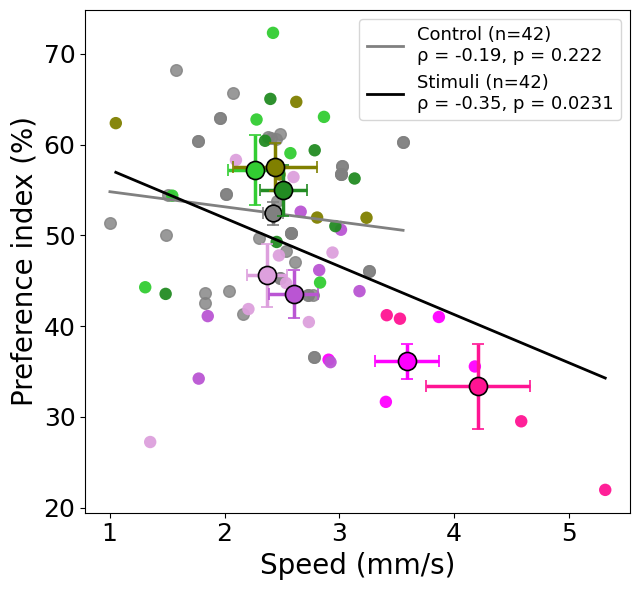

In [31]:
plot_preference_vs(
    results_df,
    "speed_quarter",
    "Speed (mm/s)",
    corr_method="spearman",
    show_means=True
    
)

### Add angle analysis to the result dataframe 

In [32]:
def summarize_experiment_angles(
    fish_list,
    frame_rate=30,
    bout_threshold=0.5,
    bout_min_duration=1,
    bout_expand=1,
    bout_gap_tolerance=2,
    bout_max_speed=3.0
):
    """
    Slow experiment summary: bout-angle metrics only.
    """

    fish_angle_change_half = compute_fish_bout_angle_changes(
        fish_list,
        x_limit=7,
        last_half_only=True,
        bout_threshold=bout_threshold,
        bout_min_duration=bout_min_duration,
        bout_expand=bout_expand,
        bout_gap_tolerance=bout_gap_tolerance,
        bout_max_speed=bout_max_speed
    )
    angle_change_half = np.nanmean(fish_angle_change_half) if len(fish_angle_change_half) > 0 else np.nan

    fish_angle_change_quarter = compute_fish_bout_angle_changes(
        fish_list,
        x_limit=3.5,
        last_half_only=True,
        bout_threshold=bout_threshold,
        bout_min_duration=bout_min_duration,
        bout_expand=bout_expand,
        bout_gap_tolerance=bout_gap_tolerance,
        bout_max_speed=bout_max_speed
    )
    angle_change_quarter = np.nanmean(fish_angle_change_quarter) if len(fish_angle_change_quarter) > 0 else np.nan

    return {
        "angle_change_half": angle_change_half,
        "angle_change_quarter": angle_change_quarter
    }

angle_results = []

for stimulus, conds in stimulus_data.items():
    for condition in ["stim", "control"]:
        for exp_name, fish_list in conds[condition].items():

            angle_summary = summarize_experiment_angles(
                fish_list=fish_list,
                frame_rate=30,
                bout_threshold=0.5,
                bout_min_duration=1,
                bout_expand=1,
                bout_gap_tolerance=2,
                bout_max_speed=3.0
            )

            angle_results.append({
                "stimulus": stimulus,
                "pair_key": get_pair_key(exp_name),
                "experiment": exp_name,
                "condition": condition,
                **angle_summary
            })

angle_results_df = pd.DataFrame(angle_results)

results_with_angles = results_df.merge(
    angle_results_df,
    on=["stimulus", "pair_key", "experiment", "condition"],
    how="left"
)

In [33]:
results_with_angles

,stimulus,pair_key,experiment,condition,preference_index,speed_half,speed_quarter,dispersion_half,dispersion_quarter,center_shift_half,center_shift_quarter,n_fish,angle_change_half,angle_change_quarter
0,fex_1_10,231221_G1,231221_G1_fex10,stim,59.046925,2.508638,2.573722,0.204074,0.162231,0.469983,0.362999,22,26.027791,28.951163
1,fex_1_10,231221_G2,231221_G2_fex10,stim,62.752640,2.380921,2.278875,0.220415,0.152874,0.483274,0.356475,21,25.732715,29.154606
2,fex_1_10,231220_G1,231220_G1_fex10,stim,63.043135,2.794170,2.865856,0.207096,0.187590,0.475251,0.444192,21,26.501707,26.270664
3,fex_1_10,231220_G2,231220_G2_fex10,stim,44.792158,2.918025,2.831901,0.354649,0.182235,0.755872,0.498099,21,18.976064,19.674803
4,fex_1_10,220708_G1,220708_G1_fex10,stim,72.301974,2.149464,2.422175,0.178424,0.157429,0.407805,0.417103,23,25.779144,24.865108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,quinine_100mM,231116_G2,231116_G2_qui,stim,21.949790,4.541062,5.314584,0.366561,0.332946,0.892803,0.838708,21,25.384559,28.488395
80,quinine_100mM,231123_G2,231123_G2_AFW,control,61.146666,2.449474,2.479250,0.199508,0.186064,0.434205,0.455276,17,25.693200,24.256011
81,quinine_100mM,231116_G1,231116_G1_AFW,control,57.667279,2.954548,3.022867,0.254741,0.116423,0.578051,0.358488,17,25.227607,27.032714
82,quinine_100mM,231116_G2,231116_G2_AFW,control,46.096360,2.774975,3.262187,0.257242,0.174133,0.569060,0.409100,17,26.535770,30.104864


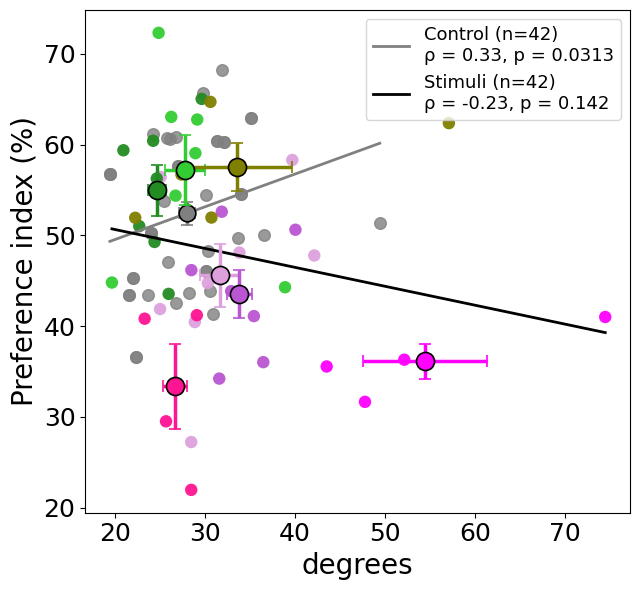

In [34]:
plot_preference_vs(results_with_angles, "angle_change_quarter", "degrees")

In [35]:
results_with_angles.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/exp_results_with_angles_stim_side.csv",
    index=False
)

### Get values per fish 

In [36]:
def summarize_fish_list(
    fish_list,
    frame_rate,
    speed_threshold=3.0,
    dispersion_bin_size=5,
    dispersion_smoothing_factor=0.5,
    include_angles=False
):
    """
    Return one row per fish with all fish-level metrics.
    """

    fish_prefs = calculate_fish_preference_indices(fish_list, frame_rate)

    fish_speed_half = compute_avg_speeds_zone(
        fish_list,
        x_limit=7,
        speed_threshold=speed_threshold
    )

    fish_speed_quarter = compute_avg_speeds_zone(
        fish_list,
        x_limit=3.5,
        speed_threshold=speed_threshold
    )

    fish_dispersion_half = compute_fish_dispersions(
        fish_list,
        x_limit=7,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )

    fish_dispersion_quarter = compute_fish_dispersions(
        fish_list,
        x_limit=3.5,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )

    fish_center_shift_half = compute_fish_center_shifts(
        fish_list,
        x_limit=7,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )

    fish_center_shift_quarter = compute_fish_center_shifts(
        fish_list,
        x_limit=3.5,
        bin_size=dispersion_bin_size,
        smoothing_factor=dispersion_smoothing_factor,
        speed_threshold=speed_threshold
    )

    fish_rows = []

    for i in range(len(fish_list)):
        row = {
            "fish_number": i,
            "preference_index": fish_prefs[i] if i < len(fish_prefs) else np.nan,
            "speed_half": fish_speed_half[i] if i < len(fish_speed_half) else np.nan,
            "speed_quarter": fish_speed_quarter[i] if i < len(fish_speed_quarter) else np.nan,
            "dispersion_half": fish_dispersion_half[i] if i < len(fish_dispersion_half) else np.nan,
            "dispersion_quarter": fish_dispersion_quarter[i] if i < len(fish_dispersion_quarter) else np.nan,
            "center_shift_half": fish_center_shift_half[i] if i < len(fish_center_shift_half) else np.nan,
            "center_shift_quarter": fish_center_shift_quarter[i] if i < len(fish_center_shift_quarter) else np.nan,
        }
        fish_rows.append(row)

    if include_angles:
        fish_angle_change_half = compute_fish_bout_angle_changes(
            fish_list,
            x_limit=7,
            last_half_only=True
        )

        fish_angle_change_quarter = compute_fish_bout_angle_changes(
            fish_list,
            x_limit=3.5,
            last_half_only=True
        )

        for i in range(len(fish_rows)):
            fish_rows[i]["angle_change_half"] = (
                fish_angle_change_half[i] if i < len(fish_angle_change_half) else np.nan
            )
            fish_rows[i]["angle_change_quarter"] = (
                fish_angle_change_quarter[i] if i < len(fish_angle_change_quarter) else np.nan
            )

    return fish_rows

In [37]:
frame_rate = 30
fish_results = []

for stimulus, conds in stimulus_data.items():
    for condition in ["stim", "control"]:
        for exp_name, fish_list in conds[condition].items():

            fish_rows = summarize_fish_list(
                fish_list=fish_list,
                frame_rate=frame_rate,
                speed_threshold=3.0,
                dispersion_bin_size=3,
                dispersion_smoothing_factor=0.5,
                include_angles=True   # set False if you want to skip slow angle analysis
            )

            for row in fish_rows:
                fish_results.append({
                    "stimulus": stimulus,
                    "pair_key": get_pair_key(exp_name),
                    "experiment": exp_name,
                    "condition": condition,
                    **row
                })

fish_results_df = pd.DataFrame(fish_results)

In [38]:
fish_results_df

,stimulus,pair_key,experiment,condition,fish_number,preference_index,speed_half,speed_quarter,dispersion_half,dispersion_quarter,center_shift_half,center_shift_quarter,angle_change_half,angle_change_quarter
0,fex_1_10,231221_G1,231221_G1_fex10,stim,0,49.944518,2.566528,2.272352,0.114949,0.114398,0.277782,0.235232,19.303878,19.468294
1,fex_1_10,231221_G1,231221_G1_fex10,stim,1,55.352160,3.546395,3.368131,0.231896,0.088650,0.622056,0.414092,23.337694,25.545301
2,fex_1_10,231221_G1,231221_G1_fex10,stim,2,42.665335,2.445459,NaN,0.091712,NaN,0.185153,NaN,25.583757,NaN
3,fex_1_10,231221_G1,231221_G1_fex10,stim,3,23.789919,2.162761,2.577979,0.198149,0.273630,0.401756,0.558234,34.564786,42.324567
4,fex_1_10,231221_G1,231221_G1_fex10,stim,4,53.951469,1.741962,NaN,0.025593,NaN,0.127062,NaN,32.873652,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,quinine_100mM,231123_G1,231123_G1_AFW,control,15,98.930839,2.917388,2.842967,0.163758,0.058843,0.328863,0.152651,18.463191,17.858433
1587,quinine_100mM,231123_G1,231123_G1_AFW,control,16,100.000000,1.825299,1.722019,0.100437,0.053132,0.201216,0.131878,29.323618,35.996338
1588,quinine_100mM,231123_G1,231123_G1_AFW,control,17,70.199044,1.935556,1.807481,0.072779,0.027427,0.160495,0.054655,23.668087,25.374138
1589,quinine_100mM,231123_G1,231123_G1_AFW,control,18,40.162114,2.806494,3.210346,0.136039,0.111510,0.329225,0.363444,21.991809,24.732763


In [26]:
# fish_results_df = fish_results_df.dropna()

In [39]:
fish_results_df.to_csv(
    "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/fish_results_df_stim_side_allfish.csv",
    index=False
)